In [93]:
!pip install pandas numpy matplotlib seaborn plotly wordcloud pyarrow


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [97]:
# ── Install dependencies (uncomment if needed) ──────────────────────────────
# !pip install pandas numpy matplotlib seaborn plotly wordcloud pyarrow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, re
from collections import Counter

warnings.filterwarnings('ignore')

# ── Plot style ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

PALETTE   = sns.color_palette('Set2')
LEVEL_CLR = {1: '#4CAF50', 2: '#FF9800', 3: '#F44336'}  # green / orange / red

print('Libraries loaded ✓')

Libraries loaded ✓


In [135]:
# ── Load dataset ─────────────────────────────────────────────────────────────
PATH = '../datasets/raw/raw_gaia.parquet'
df   = pd.read_parquet(PATH)

print(f'Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')

Shape  : 165 rows × 7 columns
Columns: ['task_id', 'Question', 'Level', 'Final answer', 'file_name', 'file_path', 'Annotator Metadata']


In [ ]:
PATH = '../datasets/golden/golden_gaia.parquet'
df   = pd.read_parquet(PATH)

print(f'Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')

In [99]:
# analyis 

In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               165 non-null    str  
 1   query            165 non-null    str  
 2   answer           165 non-null    str  
 3   level            165 non-null    str  
 4   annotator_steps  165 non-null    str  
 5   annotator_tools  165 non-null    str  
 6   file_name        165 non-null    str  
 7   steps_num        165 non-null    str  
 8   tool_num         165 non-null    str  
 9   time_taken       165 non-null    str  
dtypes: str(10)
memory usage: 193.5 KB


In [60]:
df.head()

,id,query,answer,level,annotator_steps,annotator_tools,file_name
0,c61d22de-5f6c-4958-a7f6-5e9707bd3466,A paper about AI regulation that was originall...,egalitarian,2,1. Go to arxiv.org and navigate to the Advance...,1. Web browser\n2. Image recognition tools (to...,
1,17b5a6a3-bc87-42e8-b0fb-6ab0781ef2cc,I’m researching species that became invasive a...,34689,2,1. Search the web for “finding nemo main chara...,1. Search engine\n2. Web browser,
2,04a04a9b-226c-43fd-b319-d5e89743676f,If we assume all articles published by Nature ...,41,2,1. Find how many articles were published in Na...,1. search engine\n2. calculator,
3,14569e28-c88c-43e4-8c32-097d35b9a67d,"In Unlambda, what exact charcter or text needs...",backtick,2,"1. Searched ""Unlambda syntax"" online (optional...",1. Web browser\n2. Search engine\n3. Unlambda ...,
4,e1fc63a2-da7a-432f-be78-7c4a95598703,If Eliud Kipchoge could maintain his record-ma...,17,1,1. Googled Eliud Kipchoge marathon pace to fin...,1. A web browser.\n2. A search engine.\n3. A c...,


In [104]:
print(df.loc[0, 'annotator_tools'])

1. Web browser
2. Image recognition tools (to identify and parse a figure with three axes)


In [61]:
summary = pd.DataFrame({
    'dtype'   : df.dtypes,
    'non_null': df.notnull().sum(),
    'null'    : df.isnull().sum(),
    'null_%'  : (df.isnull().mean() * 100).round(2),
    'unique'  : df.nunique(),
    'sample'  : df.iloc[0],
})
summary

,dtype,non_null,null,null_%,unique,sample
id,str,165,0,0.0,165,c61d22de-5f6c-4958-a7f6-5e9707bd3466
query,str,165,0,0.0,165,A paper about AI regulation that was originall...
answer,str,165,0,0.0,143,egalitarian
level,str,165,0,0.0,3,2
annotator_steps,str,165,0,0.0,165,1. Go to arxiv.org and navigate to the Advance...
annotator_tools,str,165,0,0.0,102,1. Web browser\n2. Image recognition tools (to...
file_name,str,165,0,0.0,39,


In [62]:
df.describe(include='all').T

,count,unique,top,freq
id,165,165,c61d22de-5f6c-4958-a7f6-5e9707bd3466,1
query,165,165,A paper about AI regulation that was originall...,1
answer,165,143,3,7
level,165,3,2,86
annotator_steps,165,165,1. Go to arxiv.org and navigate to the Advance...,1
annotator_tools,165,102,1. Web browser\n2. Search engine,22
file_name,165,39,,127


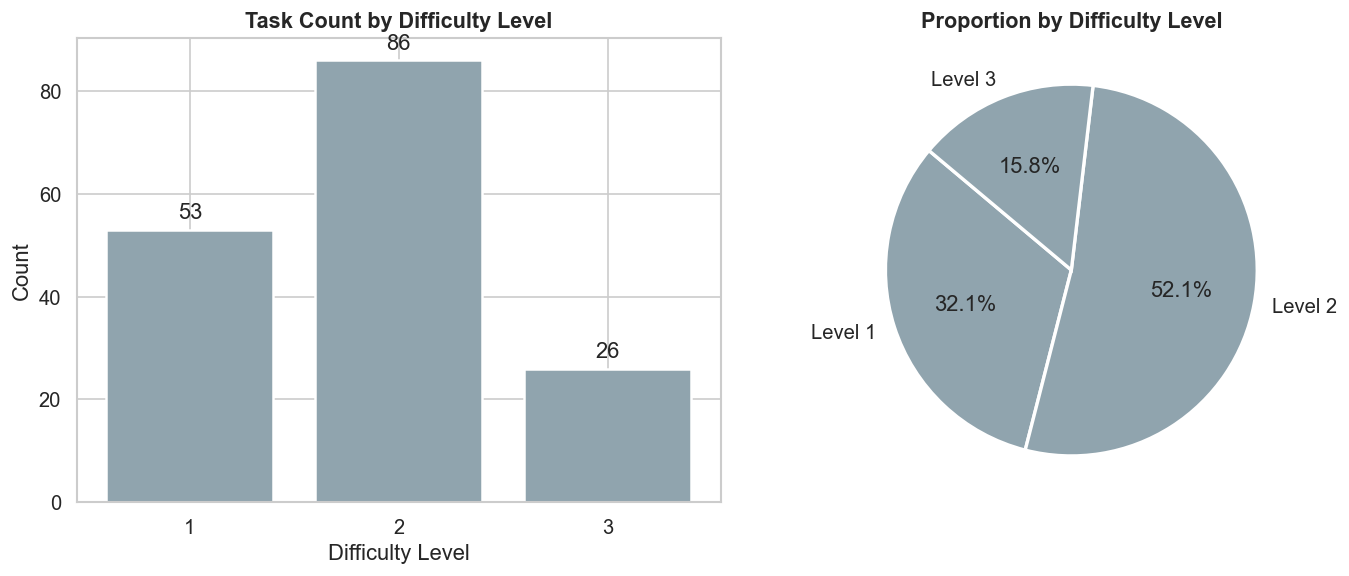

       count  percent
level                
1         53     32.1
2         86     52.1
3         26     15.8


In [63]:
# Detect the level column (handles different naming conventions)
level_col = next((c for c in df.columns if 'level' in c.lower()), None)

if level_col:
    level_counts = df[level_col].value_counts().sort_index()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Bar chart
    colors = [LEVEL_CLR.get(l, '#90A4AE') for l in level_counts.index]
    bars = ax1.bar(level_counts.index.astype(str), level_counts.values, color=colors, edgecolor='white', linewidth=1.5)
    ax1.bar_label(bars, padding=4)
    ax1.set_xlabel('Difficulty Level')
    ax1.set_ylabel('Count')
    ax1.set_title('Task Count by Difficulty Level')

    # Pie chart
    ax2.pie(level_counts.values, labels=[f'Level {l}' for l in level_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax2.set_title('Proportion by Difficulty Level')

    plt.tight_layout()
    plt.show()
    print(level_counts.to_frame('count').assign(percent=(level_counts/len(df)*100).round(1)))
else:
    print('Level column not found. Check column names:', df.columns.tolist())

In [64]:
split_col = next((c for c in df.columns if 'split' in c.lower()), None)

if split_col:
    split_counts = df[split_col].value_counts()

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(split_counts.index, split_counts.values,
                  color=sns.color_palette('pastel'), edgecolor='white', linewidth=1.5)
    ax.bar_label(bars, padding=4)
    ax.set_title('Samples per Split')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('No split column detected.')

No split column detected.


In [65]:
file_col = next((c for c in df.columns if 'file' in c.lower()), None)

if file_col:
    has_file = df['file_name'].notna() & (df['file_name'].str.strip() != '')
    counts = has_file.value_counts()

    print(counts)
    labels   = ['Has File', 'No File']

    # fig, ax = plt.subplots(figsize=(6, 4))
    # ax.pie(counts.values, labels=labels, autopct='%1.1f%%',
    #        colors=['#42A5F5', '#EF9A9A'],
    #        wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
    # ax.set_title('Tasks With vs Without File Attachments')
    # plt.tight_layout()
    # plt.show()

    print(f'Has file : {has_file.sum():>4}  ({has_file.mean()*100:.1f}%)')
    print(f'No file  : {(~has_file).sum():>4}  ({(~has_file).mean()*100:.1f}%)')
else:
    print('No file column detected.')

file_name
False    127
True      38
Name: count, dtype: int64
Has file :   38  (23.0%)
No file  :  127  (77.0%)


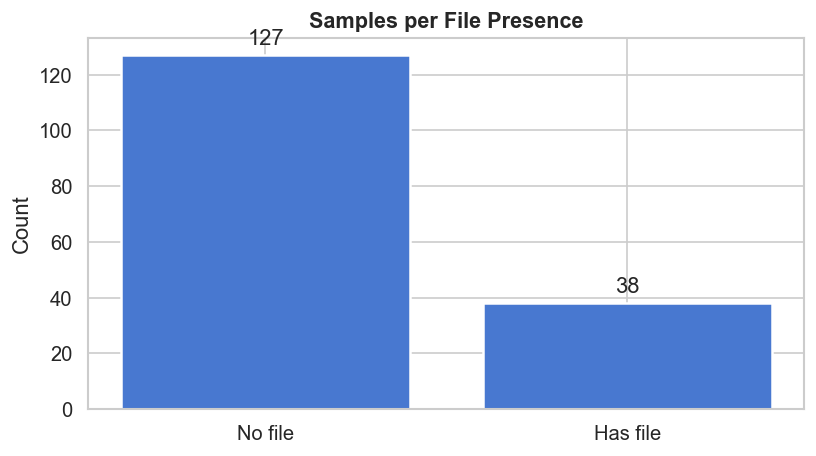

In [66]:
has_file = df['file_name'].notna() & (df['file_name'].str.strip() != '')
split_counts = has_file.map({True: 'Has file', False: 'No file'}).value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(split_counts.index, split_counts.values,
              edgecolor='white', linewidth=1.5)

ax.bar_label(bars, padding=4)
ax.set_title('Samples per File Presence')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [67]:
if level_col and split_col:
    ct = pd.crosstab(df[level_col], df[split_col], margins=True)
    display(ct)

    # Normalised heatmap
    ct_norm = pd.crosstab(df[level_col], df[split_col], normalize='index').round(3) * 100

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(ct_norm, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=.5, ax=ax, cbar_kws={'label': '%'})
    ax.set_title('Level × Split Distribution (row %)')
    plt.tight_layout()
    plt.show()
else:
    print('Level or split column not found.')

Level or split column not found.


In [68]:
steps_col = next((c for c in df.columns if 'number of steps' in c.lower()), None)
tools_col = next((c for c in df.columns if 'number of tools' in c.lower()), None)

In [69]:
print(steps_col)

None


answer


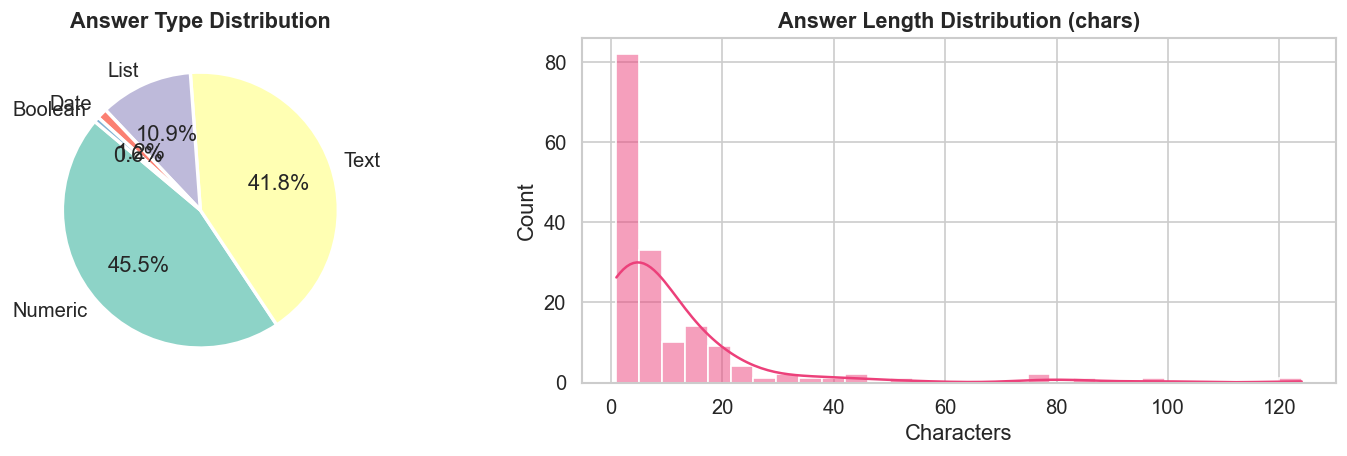

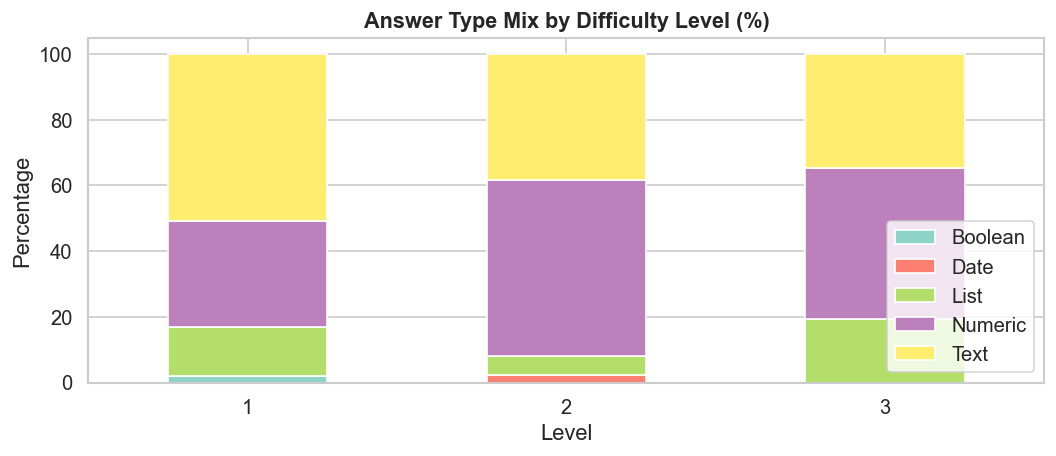

In [70]:
ans_col = next((c for c in df.columns
                if 'answer' in c.lower() or 'final' in c.lower()), None)

print(ans_col)

if ans_col:
    df['_ans_len'] = df[ans_col].astype(str).str.len()

    # Classify answer type
    def classify_answer(text):
        t = str(text).strip()
        if re.fullmatch(r'-?\d+(\.\d+)?', t):       return 'Numeric'
        if re.fullmatch(r'\d{1,2}/\d{1,2}/\d{2,4}', t): return 'Date'
        if t.lower() in ('yes','no','true','false'):  return 'Boolean'
        if ',' in t:                                  return 'List'
        return 'Text'

    df['_ans_type'] = df[ans_col].apply(classify_answer)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Answer type distribution
    ans_type_counts = df['_ans_type'].value_counts()
    axes[0].pie(ans_type_counts.values, labels=ans_type_counts.index,
                autopct='%1.1f%%', startangle=140,
                colors=sns.color_palette('Set3', len(ans_type_counts)),
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[0].set_title('Answer Type Distribution')

    # Answer length distribution
    sns.histplot(df['_ans_len'], bins=30, kde=True, color='#EC407A', ax=axes[1])
    axes[1].set_title('Answer Length Distribution (chars)')
    axes[1].set_xlabel('Characters')

    plt.tight_layout()
    plt.show()

    # Answer type vs level
    if level_col:
        ct = pd.crosstab(df[level_col], df['_ans_type'], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, figsize=(9, 4),
                colormap='Set3', edgecolor='white')
        plt.title('Answer Type Mix by Difficulty Level (%)')
        plt.xlabel('Level')
        plt.ylabel('Percentage')
        plt.xticks(rotation=0)
        plt.legend(loc='lower right')
        plt.tight_layout()
        plt.show()
else:
    print('Answer column not found.')

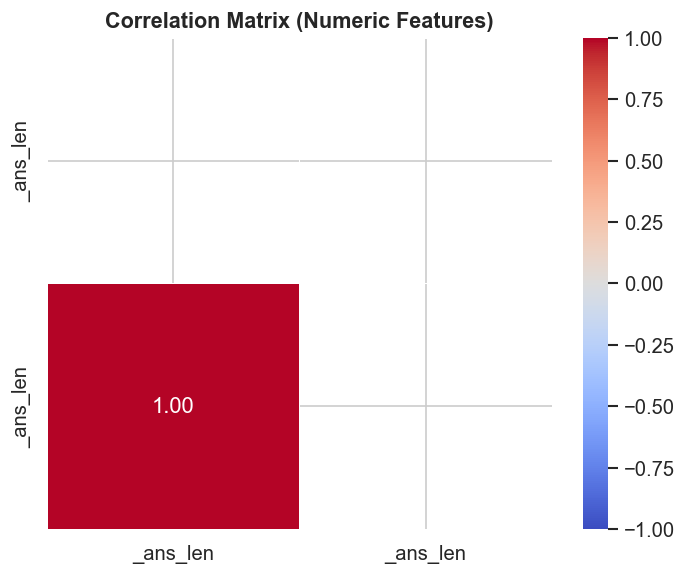

In [75]:
numeric_df = df.select_dtypes(include='number')

# Include engineered numeric columns
extra = [c for c in ['_q_len_words','_q_len_chars','_ans_len'] if c in df.columns]
if extra:
    numeric_df = pd.concat([numeric_df, df[extra]], axis=1)

numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]  # drop constants

if numeric_df.shape[1] >= 2:
    corr = numeric_df.corr()

    fig, ax = plt.subplots(figsize=(max(6, corr.shape[0]), max(5, corr.shape[0]-1)))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, linewidths=0.5, ax=ax,
                vmin=-1, vmax=1)
    ax.set_title('Correlation Matrix (Numeric Features)')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a correlation matrix.')

In [76]:
print(df.columns.tolist())

['id', 'query', 'answer', 'level', 'annotator_steps', 'annotator_tools', 'file_name', '_ans_len', '_ans_type']


In [77]:
print(df[['_ans_len', '_ans_type']].head())

   _ans_len _ans_type
0        11      Text
1         5   Numeric
2         2   Numeric
3         8      Text
4         2   Numeric


In [78]:
df[['id', '_ans_len', '_ans_type']].head()

,id,_ans_len,_ans_type
0,c61d22de-5f6c-4958-a7f6-5e9707bd3466,11,Text
1,17b5a6a3-bc87-42e8-b0fb-6ab0781ef2cc,5,Numeric
2,04a04a9b-226c-43fd-b319-d5e89743676f,2,Numeric
3,14569e28-c88c-43e4-8c32-097d35b9a67d,8,Text
4,e1fc63a2-da7a-432f-be78-7c4a95598703,2,Numeric


In [79]:
df[['id', '_ans_len', '_ans_type']].head()

,id,_ans_len,_ans_type
0,c61d22de-5f6c-4958-a7f6-5e9707bd3466,11,Text
1,17b5a6a3-bc87-42e8-b0fb-6ab0781ef2cc,5,Numeric
2,04a04a9b-226c-43fd-b319-d5e89743676f,2,Numeric
3,14569e28-c88c-43e4-8c32-097d35b9a67d,8,Text
4,e1fc63a2-da7a-432f-be78-7c4a95598703,2,Numeric


In [82]:
print('=' * 60)
print('       GAIA DATASET — EDA SUMMARY')
print('=' * 60)

print(f'\n📦  Total samples     : {len(df):,}')
print(f'📋  Total columns     : {df.shape[1]}')
print(f'❌  Columns w/ nulls  : {(df.isnull().sum() > 0).sum()}')

if level_col:
    lc = df[level_col].value_counts().sort_index()
    print(f'\n📊  Difficulty spread :')
    for lvl, cnt in lc.items():
        bar = '█' * int(cnt / len(df) * 40)
        print(f'     Level {lvl}: {cnt:>4} ({cnt/len(df)*100:5.1f}%)  {bar}')

if split_col:
    sc = df[split_col].value_counts()
    print(f'\n🔀  Splits            : {", ".join(f"{k}={v}" for k,v in sc.items())}')

if file_col:
    hf = (df[file_col].notna() & (df[file_col].astype(str).str.strip() != '')).mean()
    print(f'\n📎  Tasks with files  : {hf*100:.1f}%')

if '_q_len_words' in df.columns:
    print(f'\n💬  Avg question len  : {df["_q_len_words"].mean():.1f} words  '
          f'(median={df["_q_len_words"].median():.0f})')

if '_ans_type' in df.columns:
    top_ans = df['_ans_type'].value_counts().idxmax()
    print(f'\n✅  Most common answer type: {top_ans}')

print('\n' + '=' * 60)

       GAIA DATASET — EDA SUMMARY

📦  Total samples     : 165
📋  Total columns     : 9
❌  Columns w/ nulls  : 0

📊  Difficulty spread :
     Level 1:   53 ( 32.1%)  ████████████
     Level 2:   86 ( 52.1%)  ████████████████████
     Level 3:   26 ( 15.8%)  ██████

📎  Tasks with files  : 23.0%

✅  Most common answer type: Numeric



In [105]:
# basic stats
df[["steps_num", "tool_num", "time_taken"]].describe()

,steps_num,tool_num,time_taken
count,165,165,165
unique,21,8,30
top,6,2,5 minutes
freq,20,60,50


In [113]:
df["steps_num"] = pd.to_numeric(df["steps_num"], errors="coerce")

In [114]:
df["steps_num"].value_counts().sort_index()

steps_num
1.0      3
2.0      7
3.0     13
4.0     19
5.0     17
6.0     20
7.0     15
8.0     15
9.0     16
10.0     7
11.0     4
12.0    11
13.0     4
14.0     6
15.0     1
17.0     1
20.0     2
24.0     1
32.0     1
44.0     1
Name: count, dtype: int64

In [109]:
df["tool_num"].value_counts().sort_index()

tool_num
      1
0    10
1    21
2    60
3    47
4    24
5     1
6     1
Name: count, dtype: int64

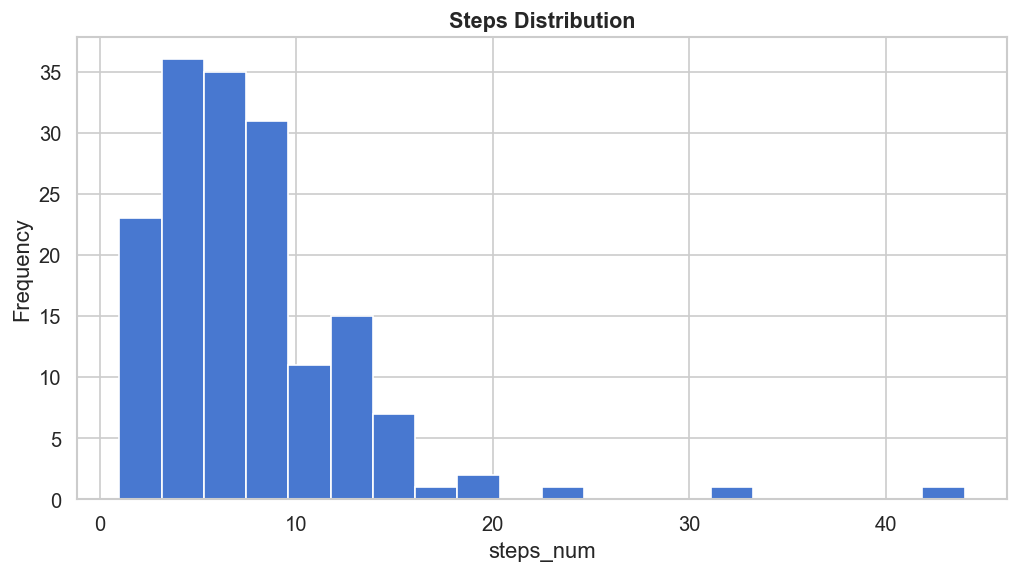

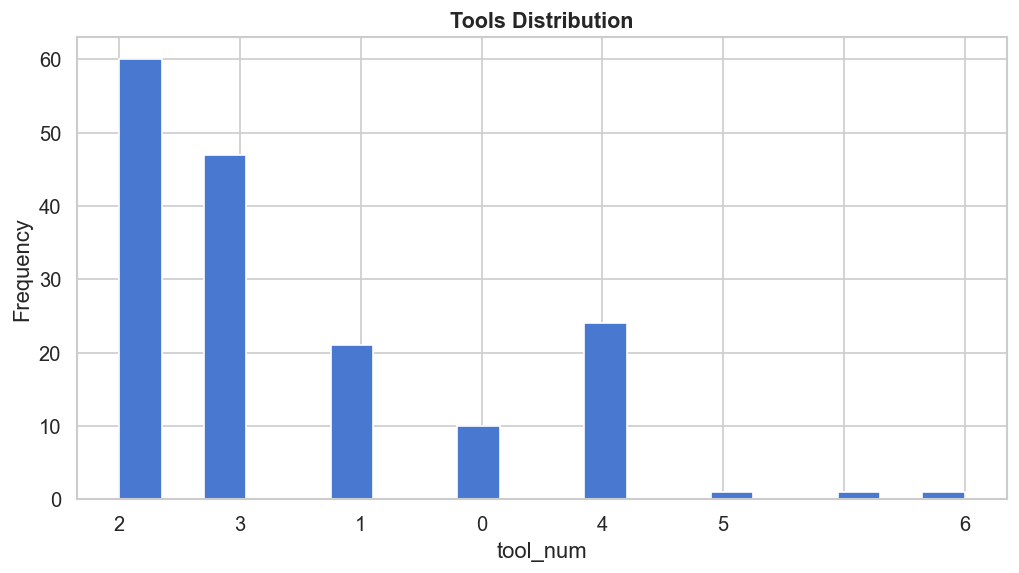

In [115]:
import matplotlib.pyplot as plt

# steps_num
plt.hist(df["steps_num"].dropna(), bins=20)
plt.title("Steps Distribution")
plt.xlabel("steps_num")
plt.ylabel("Frequency")
plt.show()

# tool_num
plt.hist(df["tool_num"].dropna(), bins=20)
plt.title("Tools Distribution")
plt.xlabel("tool_num")
plt.ylabel("Frequency")
plt.show()

In [125]:
df_lvl1 = df["level"] == "1"

In [127]:
df["level"] = pd.to_numeric(df["level"], errors="coerce")

In [128]:
df_lvl1 = df[df["level"] == 1]

In [129]:
df_lvl1 = df[df["level"] == 1]

df_lvl1["steps_num"].value_counts().sort_index()
df_lvl1["tool_num"].value_counts().sort_index()

tool_num
      1
0    10
1    12
2    20
3    10
Name: count, dtype: int64

In [130]:
print("Steps distribution:")
print(df_lvl1["steps_num"].value_counts().sort_index())

print("\nTools distribution:")
print(df_lvl1["tool_num"].value_counts().sort_index())

Steps distribution:
steps_num
1.0     3
2.0     6
3.0     7
4.0     9
5.0     3
6.0     6
7.0     6
8.0     6
9.0     4
10.0    1
12.0    1
15.0    1
Name: count, dtype: int64

Tools distribution:
tool_num
      1
0    10
1    12
2    20
3    10
Name: count, dtype: int64


In [131]:
print("Steps distribution:")
print(df_lvl1["steps_num"].value_counts().sort_index())

print("\nTools distribution:")
print(df_lvl1["tool_num"].value_counts().sort_index())

Steps distribution:
steps_num
1.0     3
2.0     6
3.0     7
4.0     9
5.0     3
6.0     6
7.0     6
8.0     6
9.0     4
10.0    1
12.0    1
15.0    1
Name: count, dtype: int64

Tools distribution:
tool_num
      1
0    10
1    12
2    20
3    10
Name: count, dtype: int64


In [132]:
steps_dist = df_lvl1["steps_num"].value_counts().sort_index()
tools_dist = df_lvl1["tool_num"].value_counts().sort_index()

combined = pd.concat([steps_dist, tools_dist], axis=1)
combined.columns = ["steps_count", "tools_count"]

combined


,steps_count,tools_count
1.0,3.0,NaN
2.0,6.0,NaN
3.0,7.0,NaN
4.0,9.0,NaN
5.0,3.0,NaN
6.0,6.0,NaN
7.0,6.0,NaN
8.0,6.0,NaN
9.0,4.0,NaN
10.0,1.0,NaN


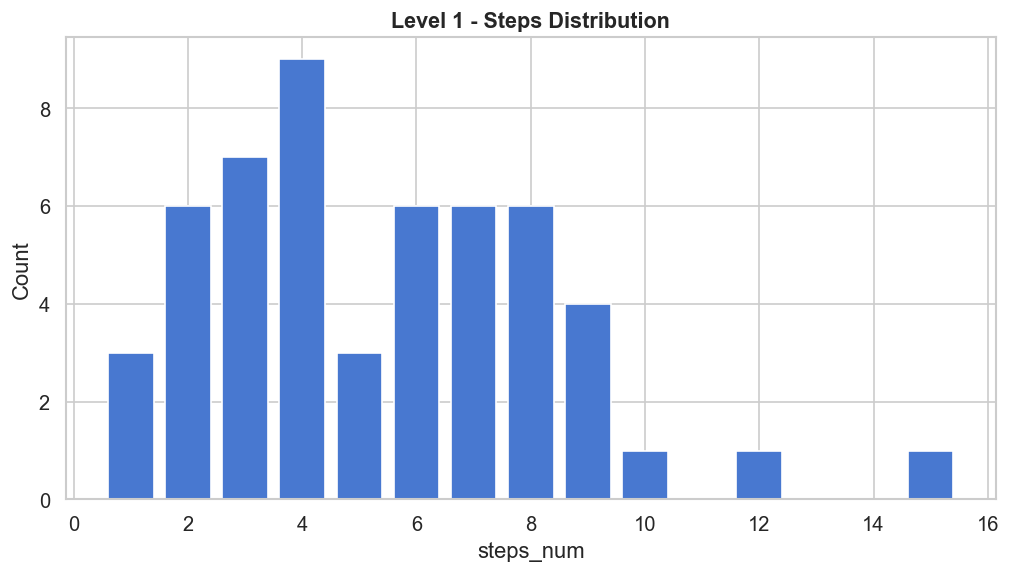

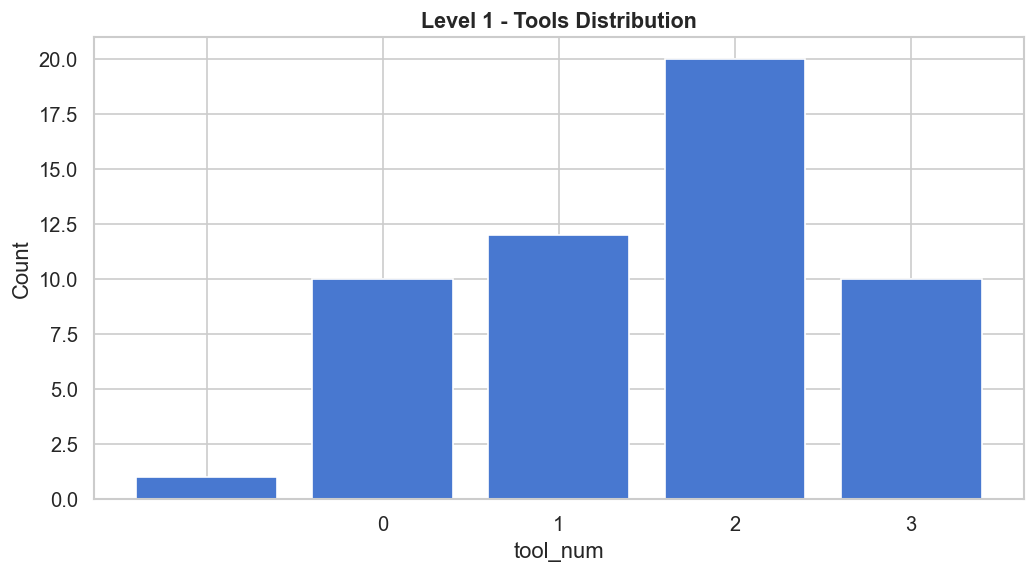

In [133]:
import matplotlib.pyplot as plt

# Prepare data
steps_dist = df_lvl1["steps_num"].value_counts().sort_index()
tools_dist = df_lvl1["tool_num"].value_counts().sort_index()

# Plot Steps Distribution
plt.figure()
plt.bar(steps_dist.index, steps_dist.values)
plt.title("Level 1 - Steps Distribution")
plt.xlabel("steps_num")
plt.ylabel("Count")
plt.show()

# Plot Tools Distribution
plt.figure()
plt.bar(tools_dist.index, tools_dist.values)
plt.title("Level 1 - Tools Distribution")
plt.xlabel("tool_num")
plt.ylabel("Count")
plt.show()

In [126]:
df_lvl1

0      False
1      False
2      False
3      False
4       True
       ...  
160    False
161    False
162    False
163    False
164    False
Name: level, Length: 165, dtype: bool

In [123]:
df["level"].unique()

<ArrowStringArray>
['2', '1', '3']
Length: 3, dtype: str

In [124]:
df["level"].value_counts()

level
2    86
1    53
3    26
Name: count, dtype: int64

In [122]:
df_lvl1["steps_num"].value_counts().sort_index()

KeyError: 'steps_num'